In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

def contar_nulos(df, columna):
    """
    Cuenta y muestra los valores faltantes en una columna 
    """
    total_nulos = df[columna].isnull().sum()
    print(f"Valores faltantes en {columna}: {total_nulos}")
    return total_nulos

def analizar_columna(df, columna):
    """
    Muestra estadísticas descriptivas y conteo de valores para una columna
    """
    print(f"--- Resumen de: {columna} ---")
    print("\n📊 Estadísticas Descriptivas:")
    print(df[columna].describe())
    
    print("\n🔢 Conteo de Valores (Frecuencias):")
    print(df[columna].value_counts())
    print("-" * 30)


## demo_h

### Limpieza Demo_H

In [28]:
df = pd.read_csv("../data/interim/demo_h_columnas.csv")

mapeo_nombres = {
    "SEQN": "ID",
    "RIAGENDR": "Genero",
    "RIDAGEYR": "Edad",
    "RIDRETH3": "Etnia",
    "DMDEDUC2": "Nivel_Educativo",
    "DMDMARTL": "Estado_Civil",
    "INDFMPIR": "Ratio_Pobreza",
    "DMQMILIZ": "Servicio_Militar",
}

df= df.rename(columns=mapeo_nombres)

df = df[df["Edad"] >= 18]

df.head()

### Mapeo de numeros a columnas (opcional) (one-hot enconding)
""" mapeo_etnia = {
    1: "Mexicano_Americano",
    2: "Otro_Hispano",
    3: "Blanco_No_Hispano",
    4: "Negro_No_Hispano",
    6: "Asiatico_No_Hispano",
    7: "Otra_Raza_Multi"
}

df['Etnia'] = df['Etnia'].map(mapeo_etnia)

# mapeo de atributos a columnas True o False
df = pd.get_dummies(df, columns=['Etnia'], prefix='Etnia')

df.head() """

## Limpieza de edad
analizar_columna(df,'Edad')
contar_nulos(df,'Edad')


## Limpieza de Nivel_Educativo
#discrepancia de 344, personas menores a 20 ya que nivel_educativo solo aplica para mayores de 20

analizar_columna(df,'Nivel_Educativo')
contar_nulos(df,'Nivel_Educativo')

def traducir_educacion_juvenil(valor_juvenil):
    if pd.isna(valor_juvenil):
        return np.nan
    
    # Códigos de NHANES para DMDEDUC3 -> DMDEDUC2
    if valor_juvenil in [0, 1, 2, 3, 4, 5, 6, 7, 8, 55, 66]:
        return 1  # Menos de 9no grado
    elif valor_juvenil in [9, 10, 11, 12]:
        return 2  # 9-11 grado (o 12 sin diploma)
    elif valor_juvenil in [13, 14]:
        return 3  # Graduado High School / GED
    elif valor_juvenil == 15:
        return 4  # Algo de universidad
    else:
        return np.nan # Códigos raros (77, 99)

mask_nulos = df['Nivel_Educativo'].isna()
            
df.loc[mask_nulos, 'Nivel_Educativo'] = df.loc[mask_nulos, 'DMDEDUC3'].apply(traducir_educacion_juvenil)

# Filtrado solo por valores validos
df = df[df['Nivel_Educativo'].isin([1, 2, 3, 4, 5])]




## Limpieza de Estado_Civil
# Los menores de edad (NaN) los remplazamos por Nunca Casados.

analizar_columna(df,"Estado_Civil")
contar_nulos(df,"Estado_Civil")

df["Estado_Civil"] = df["Estado_Civil"].replace({77.0: 5, 99.0: 5}).fillna(5)



## Limpieza de Servicio_Militar
# Reemplazar los valores 7 por 2 (No)
contar_nulos(df,"Servicio_Militar")
analizar_columna(df,"Servicio_Militar")

df["Servicio_Militar"] = df["Servicio_Militar"].replace({7: 2})



## Limpieza de Ratio Pobreza
analizar_columna(df,'Ratio_Pobreza')
contar_nulos(df,'Ratio_Pobreza')
#Rellnar los nulos con 0 no es correcto, puesto que los nulos son falta de informacion y 0 tiene un significado real.  
#INDFMPIR: This variable is the ratio of family income to poverty. The Department of Health and Human Services (HHS) poverty guidelines were used as the poverty measure to calculate this ratio. These guidelines are issued each year, in the Federal Register, for determining financial eligibility for certain federal programs, such as Head Start, Supplemental Nutrition Assistance Program (SNAP), Special Supplemental Nutrition Program for Women, Infants, and Children (WIC), and the National School Lunch Program. The poverty guidelines vary by family size and geographic location (with different guidelines for the 48 contiguous states and the District of Columbia; Alaska; and Hawaii).
#INDFMPIR was calculated by dividing family (or individual) income by the poverty guidelines specific to the survey year. The value was not computed if the respondent only reported income as < $20,000 or ≥ $20,000. If family income was reported as a more detailed category, the midpoint of the range was used to compute the ratio. Values at or above 5.00 were coded as 5.00 or more because of disclosure concerns. The values were not computed if the income data was missing.

# Crear una columna bandera (1 si era nulo, 0 si no)
df["Ratio_Pobreza_Faltante"] = df["Ratio_Pobreza"].isnull().astype(int)
# Rellenar el nulo con la mediana
mediana_pobreza = df["Ratio_Pobreza"].median()
df["Ratio_Pobreza"] = df["Ratio_Pobreza"].fillna(mediana_pobreza)




--- Resumen de: Edad ---

📊 Estadísticas Descriptivas:
count   6113.00
mean      47.39
std       18.47
min       18.00
25%       32.00
50%       47.00
75%       62.00
max       80.00
Name: Edad, dtype: float64

🔢 Conteo de Valores (Frecuencias):
Edad
80.00    352
18.00    191
19.00    153
63.00    119
30.00    117
        ... 
76.00     51
75.00     51
77.00     38
78.00     36
79.00     30
Name: count, Length: 63, dtype: int64
------------------------------
Valores faltantes en Edad: 0
--- Resumen de: Nivel_Educativo ---

📊 Estadísticas Descriptivas:
count   5769.00
mean       3.52
std        1.24
min        1.00
25%        3.00
50%        4.00
75%        5.00
max        9.00
Name: Nivel_Educativo, dtype: float64

🔢 Conteo de Valores (Frecuencias):
Nivel_Educativo
4.00    1770
5.00    1443
3.00    1303
2.00     791
1.00     455
9.00       5
7.00       2
Name: count, dtype: int64
------------------------------
Valores faltantes en Nivel_Educativo: 344
--- Resumen de: Estado_Civil ---



In [29]:
df = df.drop(columns=['DMDEDUC3'])

df.to_csv('../data/demo.csv', index=False)

### Visualizacion de DEMO_H

In [30]:
df.head()

,ID,Genero,Edad,Etnia,Nivel_Educativo,Estado_Civil,Ratio_Pobreza,Servicio_Militar,Ratio_Pobreza_Faltante
0,73557.00,1.00,69.00,4.00,3.00,4.00,0.84,1.00,0
1,73558.00,1.00,54.00,3.00,3.00,1.00,1.78,2.00,0
2,73559.00,1.00,72.00,3.00,4.00,1.00,4.51,1.00,0
4,73561.00,2.00,73.00,3.00,5.00,1.00,5.00,2.00,0
5,73562.00,1.00,56.00,1.00,4.00,3.00,4.79,1.00,0


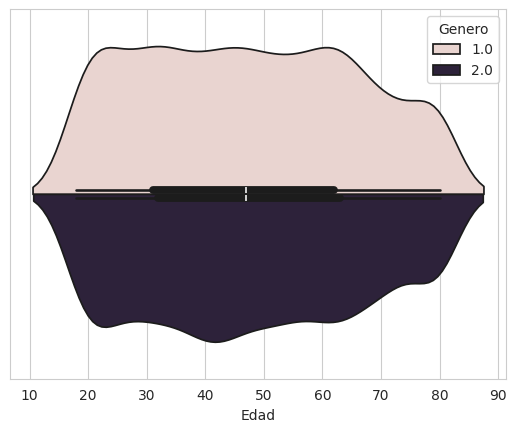

In [31]:
sns.violinplot(data=df, x="Edad", hue="Genero", split=True)
plt.show()

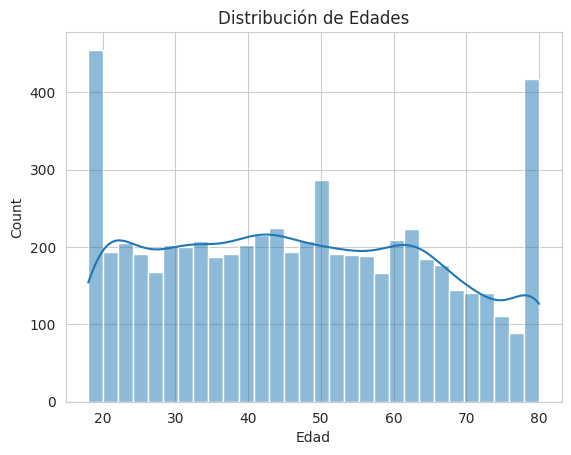

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="Edad", bins=30, kde=True)
plt.title("Distribución de Edades")
plt.show()

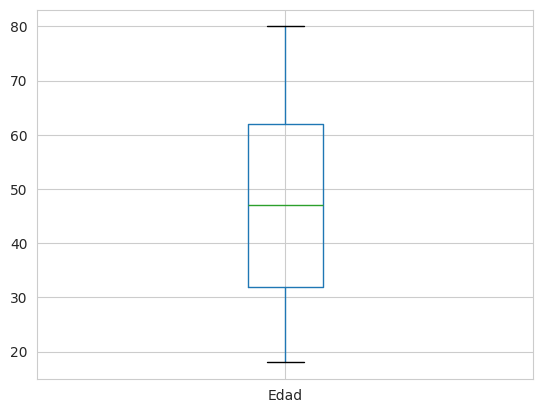

In [33]:
df.boxplot(column=['Edad'])
plt.show()


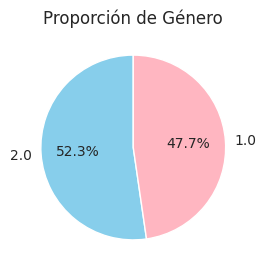

In [34]:
plt.figure(figsize=(3, 3))
df['Genero'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'lightpink'], startangle=90)

plt.title('Proporción de Género')
plt.ylabel('') # Elimina la etiqueta lateral para que se vea limpio
plt.show()

/tmp/ipykernel_4917/251591813.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Educacion_Label', data=df, order=orden_logico, palette='magma')


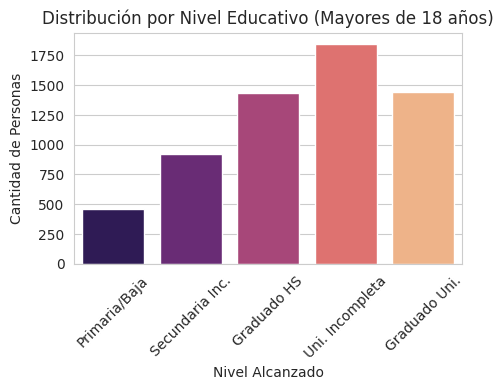

In [35]:
# Diccionario basado en lo que unificamos
nombres_educacion = {
    1: "Primaria/Baja",
    2: "Secundaria Inc.",
    3: "Graduado HS",
    4: "Uni. Incompleta",
    5: "Graduado Uni."
}

# Creamos una columna temporal para el gráfico
df['Educacion_Label'] = df['Nivel_Educativo'].map(nombres_educacion)

plt.figure(figsize=(5, 3))

# Usamos el orden lógico del 1 al 5
orden_logico = ["Primaria/Baja", "Secundaria Inc.", "Graduado HS", "Uni. Incompleta", "Graduado Uni."]

sns.countplot(x='Educacion_Label', data=df, order=orden_logico, palette='magma')

plt.title('Distribución por Nivel Educativo (Mayores de 18 años)')
plt.xlabel('Nivel Alcanzado')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45) # Rotamos los nombres para que no se amontonen
plt.show()

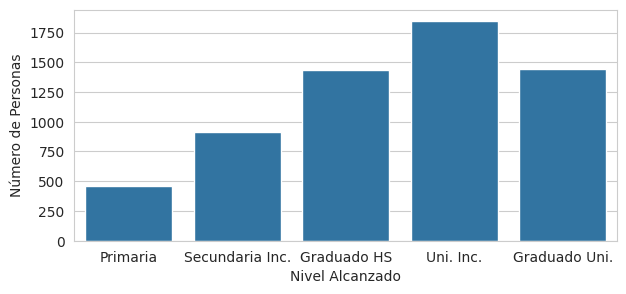

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid") 
plt.figure(figsize=(7, 3))

sns.countplot(x='Nivel_Educativo', data=df,)

plt.xticks(ticks=[0, 1, 2, 3, 4], 
           labels=['Primaria', 'Secundaria Inc.', 'Graduado HS', 'Uni. Inc.', 'Graduado Uni.'])

plt.xlabel("Nivel Alcanzado")
plt.ylabel("Número de Personas")
plt.show()

## ALQ

### Limpieza alq

In [37]:
df = pd.read_csv("../data/interim/alq_h_columnas.csv")

nuevos_nombres = {
    "ALQ120Q": "Frec_Consumo_Anual",
    "ALQ120U": "Unidad_Frec_Anual",
    "ALQ130":  "Promedio_Tragos_Dia",
    "ALQ141Q": "Dias_4_5_Tragos",
    "ALQ141U": "Unidad_4_5_Tragos", 
    "ALQ160":  "Dias_Con_+4_5_Tragos_En_2hrs"
}

# Aplicar el cambio
df = df.rename(columns=nuevos_nombres)

# Marcar 0s en columnas relevantes para personas que no han consumido alcohol

# Redondear 
df['Frec_Consumo_Anual'] = df['Frec_Consumo_Anual'].round(2)
df['Dias_4_5_Tragos'] = df['Dias_4_5_Tragos'].round(2)
df['Dias_Con_+4_5_Tragos_En_2hrs'] = df['Dias_Con_+4_5_Tragos_En_2hrs'].round(2)


# Creamos una columna si ha consumido alcohol en toda su vida
df['Consumio_Alcohol'] = ((df['ALQ101'] == 1) | (df['ALQ110'] == 1)) & (df['Frec_Consumo_Anual'] > 0)


# Definimos la lista de columnas que queremos poner en 0
columnas_relevantes = [
    "Frec_Consumo_Anual",
    "Unidad_Frec_Anual",
    "Promedio_Tragos_Dia",
    "Dias_4_5_Tragos",
    "Unidad_4_5_Tragos", 
    "Dias_Con_+4_5_Tragos_En_2hrs"
]


# Si 'Consumio_Alcohol' es False, asignamos 0 a todas esas columnas
df.loc[df['Consumio_Alcohol'] == False, columnas_relevantes] = 0

analizar_columna(df,'Consumio_Alcohol')
contar_nulos(df,'Consumio_Alcohol')


# Crearemos una sola columna Dias_Consumo_Anual para unir la frecuencia y el consumo

### Limpieza de Frec_Consumo_Anual, Mantenemos nulos
# Filtramos el dataframe para excluir las filas con 999
df = df[df['Frec_Consumo_Anual'] != 999]

# Reseteamos el índice para mantener el orden
df = df.reset_index(drop=True)
analizar_columna(df,'Frec_Consumo_Anual')
contar_nulos(df,'Frec_Consumo_Anual')



### Limpieza de Unidad_Frec_Anual
analizar_columna(df,'Unidad_Frec_Anual')
contar_nulos(df,'Unidad_Frec_Anual')
# Ya limpio



### Creacion de Dias_Consumo_Anual
factores = {1: 52, 2: 12, 3: 1}
df['Dias_Consumo_Anual'] = df['Frec_Consumo_Anual'] * df['Unidad_Frec_Anual'].map(factores)
# Como los que marcaron 0 no tienen unidad, el resultado da NaN, pero debería ser 0.
df.loc[df['Frec_Consumo_Anual'] == 0, 'Dias_Consumo_Anual'] = 0



### Limpieza Promedio_Tragos Dia

# 2 personas no saben cuanto beben al dia, las eliminaremos por simplicidad
df[df['Promedio_Tragos_Dia']==999]

# Filtramos el dataframe para excluir las filas con 999
df = df[df['Promedio_Tragos_Dia'] != 999]
# Filtramos el dataframe para excluir las filas con nulo
df = df.dropna(subset=['Promedio_Tragos_Dia'])
# Reseteamos el índice para mantener el orden
df = df.reset_index(drop=True)



### Limpieza Dias_4_5_Tragos
df['Dias_4_5_Tragos'] = df['Dias_4_5_Tragos'].round(2)

# Si alguien no bebio, ponemos 0
df.loc[df['Frec_Consumo_Anual'] == 0, 'Dias_4_5_Tragos'] = 0

# dropeamos nulos y codigos invalidos
df = df.dropna(subset=['Dias_4_5_Tragos'])
df = df[df['Dias_4_5_Tragos'] != 999]
df = df.reset_index(drop=True)



# Unidad_4_5_Tragos
# Si no has tomado 4-5 tragos en un dia, marcamos 0 en esta columna
df.loc[df['Dias_4_5_Tragos'] == 0, 'Unidad_4_5_Tragos'] = 0

analizar_columna(df,'Unidad_4_5_Tragos')
contar_nulos(df,'Unidad_4_5_Tragos')

## todo: dias_alto_consumo
#juntar Dias y Unidad 


# Dias_Con_+4_5_Tragos_En_2hrs
# si no tienes un dia con 4/5 tragos, marcar 0 
df.loc[df['Dias_4_5_Tragos'] == 0, 'Dias_Con_+4_5_Tragos_En_2hrs'] = 0
df = df[df['Dias_Con_+4_5_Tragos_En_2hrs'] != 999]
df = df.reset_index(drop=True)

analizar_columna(df,'Dias_Con_+4_5_Tragos_En_2hrs')
contar_nulos(df,'Dias_Con_+4_5_Tragos_En_2hrs')

--- Resumen de: Consumio_Alcohol ---

📊 Estadísticas Descriptivas:
count     5924
unique       2
top       True
freq      3597
Name: Consumio_Alcohol, dtype: object

🔢 Conteo de Valores (Frecuencias):
Consumio_Alcohol
True     3597
False    2327
Name: count, dtype: int64
------------------------------
Valores faltantes en Consumio_Alcohol: 0
--- Resumen de: Frec_Consumo_Anual ---

📊 Estadísticas Descriptivas:
count   5920.00
mean       2.89
std       15.19
min        0.00
25%        0.00
50%        1.00
75%        3.00
max      365.00
Name: Frec_Consumo_Anual, dtype: float64

🔢 Conteo de Valores (Frecuencias):
Frec_Consumo_Anual
0.00      2327
1.00      1046
2.00       884
3.00       524
4.00       302
5.00       265
7.00       194
6.00       141
10.00       70
20.00       24
12.00       24
8.00        23
15.00       22
30.00       20
14.00        6
365.00       6
9.00         4
25.00        4
24.00        4
40.00        2
80.00        2
11.00        2
16.00        2
100.00       2
28.

np.int64(0)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5909 entries, 0 to 5908
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SEQN                          5909 non-null   float64
 1   ALQ101                        5406 non-null   float64
 2   ALQ110                        1630 non-null   float64
 3   Frec_Consumo_Anual            5909 non-null   float64
 4   Unidad_Frec_Anual             5909 non-null   float64
 5   Promedio_Tragos_Dia           5909 non-null   float64
 6   Dias_4_5_Tragos               5909 non-null   float64
 7   Unidad_4_5_Tragos             5909 non-null   float64
 8   Dias_Con_+4_5_Tragos_En_2hrs  5909 non-null   float64
 9   Consumio_Alcohol              5909 non-null   bool   
 10  Dias_Consumo_Anual            5909 non-null   float64
dtypes: bool(1), float64(10)
memory usage: 467.5 KB


In [39]:
df = df.drop(columns=['ALQ101','ALQ110'])

df.to_csv('../data/alq.csv', index=False)